In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [84]:
DATA_DIR = Path("data")

FOLDERS = {
    "0% Fracture": DATA_DIR / "0",
    "25% Fracture": DATA_DIR / "25",
    "50% Fracture": DATA_DIR / "50",
    "90% Fracture": DATA_DIR / "90",
}

In [85]:
def find_column(df, keywords):
    """
    Find column by keyword.
    """
    for col in df.columns:
        col_lower = col.lower()

        for keyword in keywords:
            if keyword.lower() in col_lower:
                return col

    return None


def load_csv_with_phase(csv_file):
    df = pd.read_csv(csv_file)

    freq_col = find_column(df, ["freq"])
    res_col = find_column(df, ["resistance", "real"])
    react_col = find_column(df, ["reactance", "imag"])

    if freq_col is None:
        raise ValueError(f"No frequency column found in {csv_file}")

    if res_col is None:
        raise ValueError(f"No resistance column found in {csv_file}")

    if react_col is None:
        raise ValueError(f"No reactance column found in {csv_file}")

    phase_deg = np.degrees(
        np.arctan2(df[react_col], df[res_col])
    )

    return pd.DataFrame({
        "Frequency": df[freq_col],
        "Phase Angle": phase_deg
    })

In [86]:
all_data = {}

for condition, folder in FOLDERS.items():

    csv_files = sorted(folder.glob("*.csv"))

    condition_data = []

    for csv_file in csv_files:

        try:
            df = load_csv_with_phase(csv_file)

            condition_data.append({
                "file": csv_file.name,
                "data": df
            })

            print(f"Loaded: {csv_file}")

        except Exception as e:
            print(f"Failed: {csv_file}")
            print(e)

    all_data[condition] = condition_data

Loaded: data\0\sweep_20260602_131656.csv
Loaded: data\0\sweep_20260602_131705.csv
Loaded: data\0\sweep_20260602_131710.csv
Loaded: data\0\sweep_20260602_131715.csv
Loaded: data\0\sweep_20260602_131722.csv
Loaded: data\25\sweep_20260602_132802.csv
Loaded: data\25\sweep_20260602_132808.csv
Loaded: data\25\sweep_20260602_132812.csv
Loaded: data\25\sweep_20260602_132814.csv
Loaded: data\25\sweep_20260602_132817.csv
Loaded: data\25\sweep_20260602_132820.csv
Loaded: data\25\sweep_20260602_132823.csv
Loaded: data\50\sweep_20260602_133210.csv
Loaded: data\50\sweep_20260602_133213.csv
Loaded: data\50\sweep_20260602_133216.csv
Loaded: data\50\sweep_20260602_133219.csv
Loaded: data\50\sweep_20260602_133222.csv
Loaded: data\50\sweep_20260602_133225.csv
Loaded: data\50\sweep_20260602_133227.csv
Loaded: data\50\sweep_20260602_133230.csv
Loaded: data\50\sweep_20260602_133233.csv
Loaded: data\50\sweep_20260602_133235.csv
Loaded: data\50\sweep_20260602_133238.csv
Loaded: data\50\sweep_20260602_133241.c

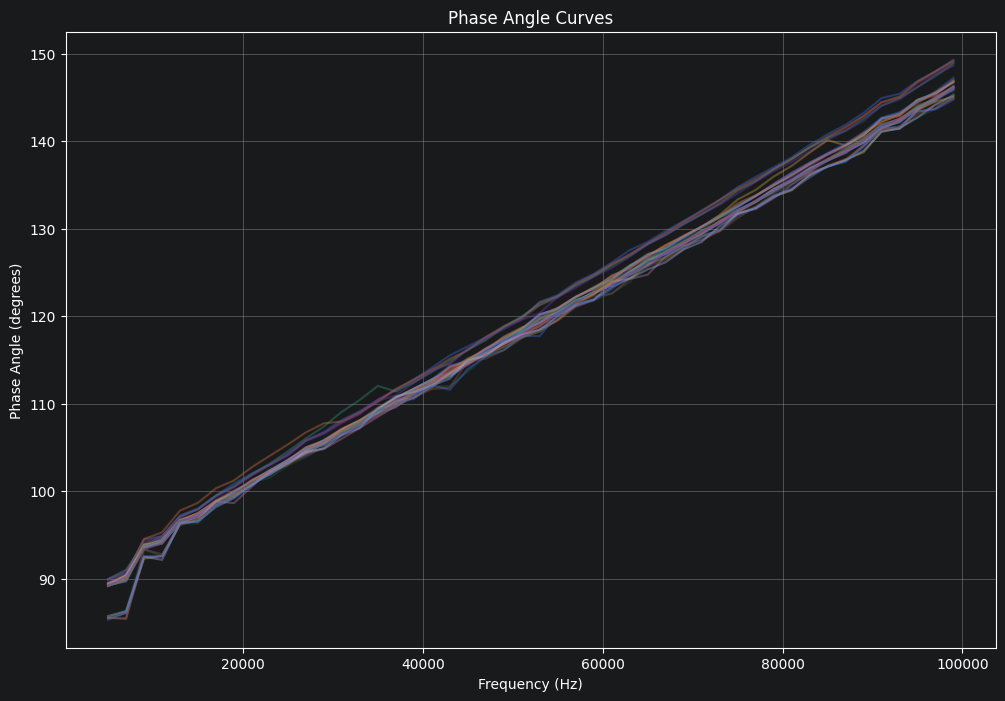

In [87]:
plt.figure(figsize=(12, 8))

for condition, datasets in all_data.items():

    for dataset in datasets:

        plt.plot(
            dataset["data"]["Frequency"],
            dataset["data"]["Phase Angle"],
            alpha=0.4,
            label=condition
        )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase Angle (degrees)")
plt.title("Phase Angle Curves")
plt.grid(True)

plt.show()

In [88]:
mean_curves = {}

for condition, datasets in all_data.items():

    if len(datasets) == 0:
        continue

    freq = datasets[0]["data"]["Frequency"]

    phase_matrix = np.column_stack([
        d["data"]["Phase Angle"]
        for d in datasets
    ])

    mean_phase = np.mean(phase_matrix, axis=1)
    std_phase = np.std(phase_matrix, axis=1)

    mean_curves[condition] = {
        "Frequency": freq,
        "Mean": mean_phase,
        "STD": std_phase
    }

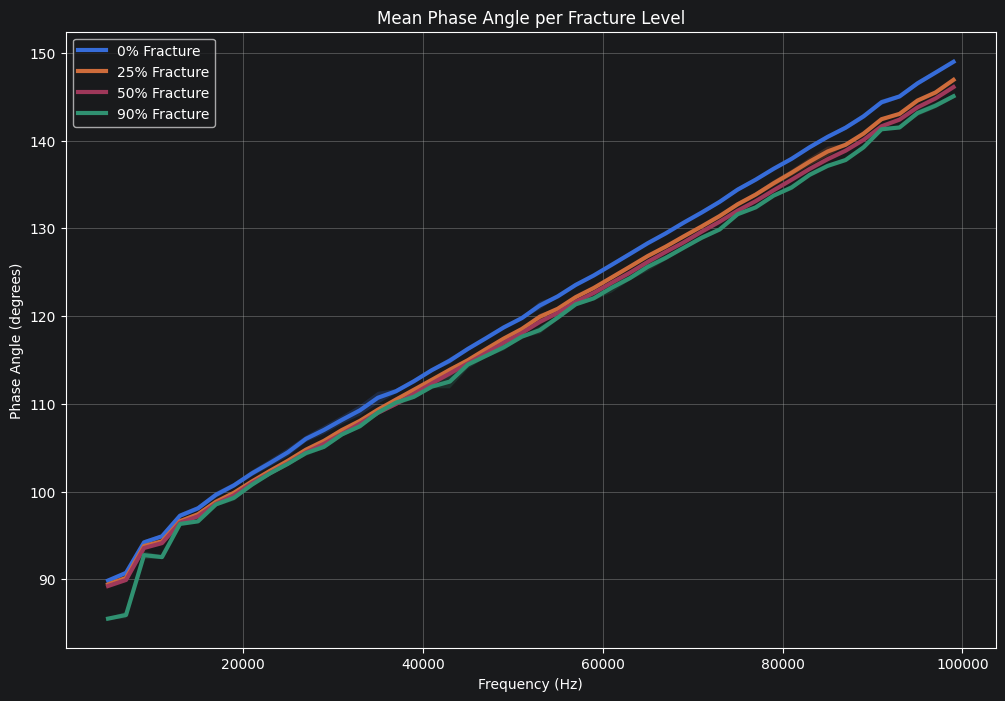

In [89]:
plt.figure(figsize=(12, 8))

for condition, data in mean_curves.items():

    plt.plot(
        data["Frequency"],
        data["Mean"],
        linewidth=3,
        label=condition
    )

    plt.fill_between(
        data["Frequency"],
        data["Mean"] - data["STD"],
        data["Mean"] + data["STD"],
        alpha=0.2
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase Angle (degrees)")
plt.title("Mean Phase Angle per Fracture Level")
plt.legend()
plt.grid(True)

plt.show()

In [90]:
summary = []

for condition, datasets in all_data.items():

    all_phases = []

    for dataset in datasets:
        all_phases.extend(
            dataset["data"]["Phase Angle"].tolist()
        )

    summary.append({
        "Condition": condition,
        "Mean Phase": np.mean(all_phases),
        "STD Phase": np.std(all_phases),
        "Min Phase": np.min(all_phases),
        "Max Phase": np.max(all_phases)
    })

summary_df = pd.DataFrame(summary)

summary_df

,Condition,Mean Phase,STD Phase,Min Phase,Max Phase
0,0% Fracture,120.419119,16.867137,89.587807,149.293091
1,25% Fracture,119.101661,16.435580,89.345220,147.227707
2,50% Fracture,118.594512,16.237164,89.163625,146.309932
3,90% Fracture,117.933153,16.359616,85.307137,145.441058


Nyquist

In [91]:
PHASE_CORRECTION_FILE = "phase_correction.csv"

phase_correction = pd.read_csv(
    PHASE_CORRECTION_FILE
)

print(
    f"Loaded {len(phase_correction)} correction points"
)

Loaded 48 correction points


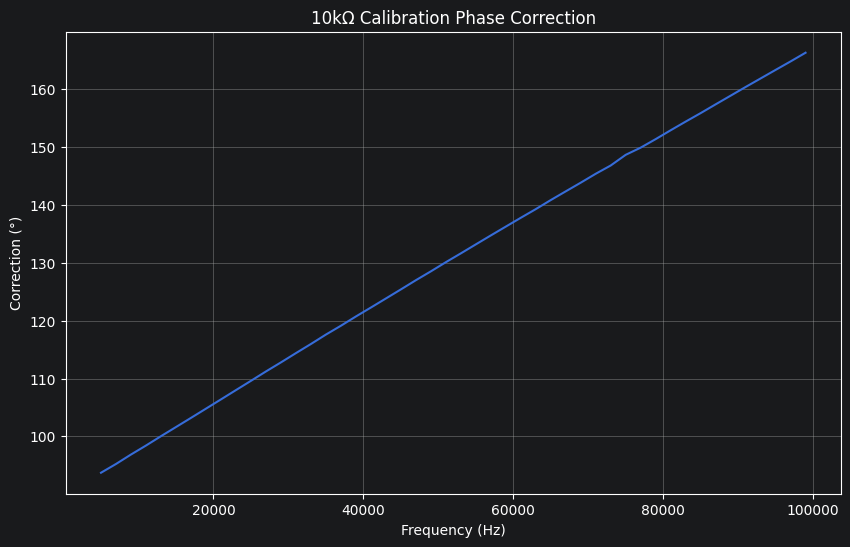

In [92]:
plt.figure(figsize=(10,6))

plt.plot(
    phase_correction["frequency"],
    phase_correction["phase_correction"]
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Correction (°)")
plt.title("10kΩ Calibration Phase Correction")
plt.grid(True)

plt.show()

In [93]:
def load_csv_for_nyquist(csv_file):

    df = pd.read_csv(csv_file)

    # Raw phase from AD5933 output
    df["phase_raw"] = np.degrees(
        np.arctan2(
            df["imaginary"],
            df["real"]
        )
    )

    # Add correction values
    df = pd.merge(
        df,
        phase_correction,
        on="frequency",
        how="left"
    )

    # Apply correction
    df["phase_corrected"] = (
        df["phase_raw"]
        - df["phase_correction"]
    )

    # Convert back to radians
    phase_rad = np.radians(
        df["phase_corrected"]
    )

    resistance = (
        df["impedance"]
        * np.cos(phase_rad)
    )

    reactance = (
        df["impedance"]
        * np.sin(phase_rad)
    )

    return pd.DataFrame({
        "Frequency": df["frequency"],
        "Resistance": resistance,
        "Reactance": reactance,
        "Phase": df["phase_corrected"],
        "Impedance": df["impedance"]
    })

In [94]:
all_data = {}

for condition, folder in FOLDERS.items():

    csv_files = sorted(folder.glob("*.csv"))

    condition_data = []

    for csv_file in csv_files:

        try:

            df = load_csv_for_nyquist(csv_file)

            condition_data.append({
                "file": csv_file.name,
                "data": df
            })

            print(f"Loaded: {csv_file.name}")

        except Exception as e:

            print(f"Failed: {csv_file.name}")
            print(e)

    all_data[condition] = condition_data

Loaded: sweep_20260602_131656.csv
Loaded: sweep_20260602_131705.csv
Loaded: sweep_20260602_131710.csv
Loaded: sweep_20260602_131715.csv
Loaded: sweep_20260602_131722.csv
Loaded: sweep_20260602_132802.csv
Loaded: sweep_20260602_132808.csv
Loaded: sweep_20260602_132812.csv
Loaded: sweep_20260602_132814.csv
Loaded: sweep_20260602_132817.csv
Loaded: sweep_20260602_132820.csv
Loaded: sweep_20260602_132823.csv
Loaded: sweep_20260602_133210.csv
Loaded: sweep_20260602_133213.csv
Loaded: sweep_20260602_133216.csv
Loaded: sweep_20260602_133219.csv
Loaded: sweep_20260602_133222.csv
Loaded: sweep_20260602_133225.csv
Loaded: sweep_20260602_133227.csv
Loaded: sweep_20260602_133230.csv
Loaded: sweep_20260602_133233.csv
Loaded: sweep_20260602_133235.csv
Loaded: sweep_20260602_133238.csv
Loaded: sweep_20260602_133241.csv
Loaded: sweep_20260602_133244.csv
Loaded: sweep_20260602_133957.csv
Loaded: sweep_20260602_134007.csv
Loaded: sweep_20260602_134014.csv
Loaded: sweep_20260602_134019.csv
Loaded: sweep_

Plot Every Nyquist Curve

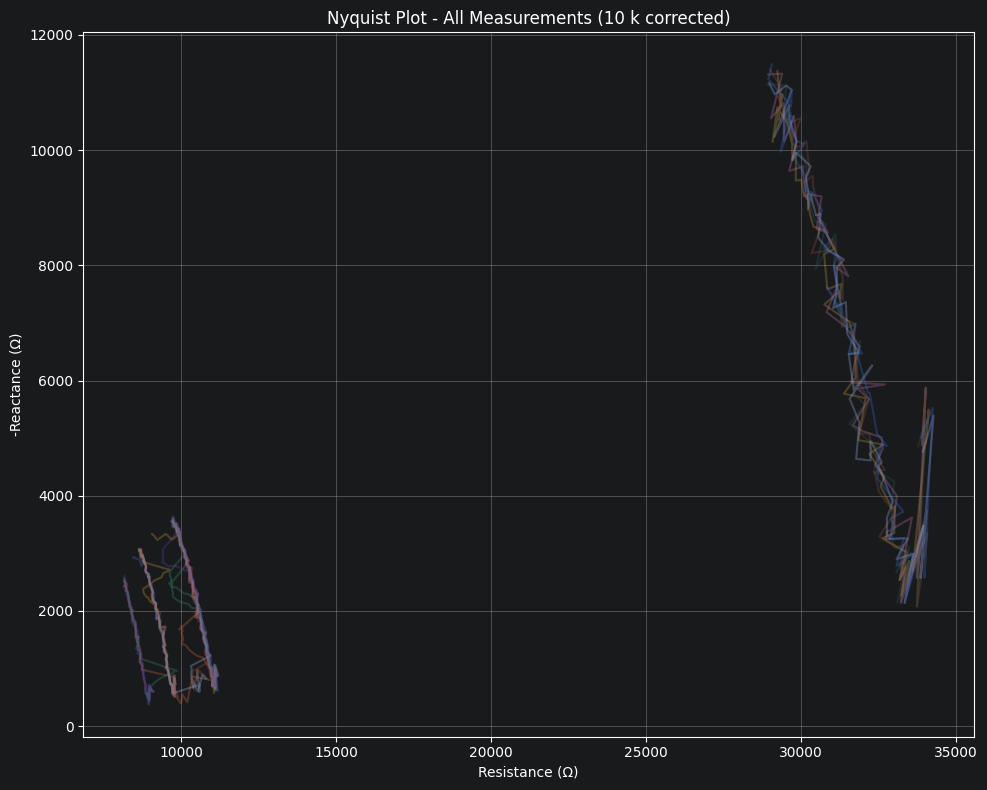

In [95]:
plt.figure(figsize=(10,8))

for condition, datasets in all_data.items():

    for dataset in datasets:

        plt.plot(
            dataset["data"]["Resistance"],
            -dataset["data"]["Reactance"],
            alpha=0.3
        )

plt.xlabel("Resistance (Ω)")
plt.ylabel("-Reactance (Ω)")
plt.title("Nyquist Plot - All Measurements (10 k corrected)")
plt.grid(True)

plt.tight_layout()
plt.show()

Average Nyquist Curves

In [96]:
mean_curves = {}

for condition, datasets in all_data.items():

    if len(datasets) == 0:
        continue

    resistance_matrix = np.column_stack([
        d["data"]["Resistance"]
        for d in datasets
    ])

    reactance_matrix = np.column_stack([
        d["data"]["Reactance"]
        for d in datasets
    ])

    phase_matrix = np.column_stack([
        d["data"]["Phase"]
        for d in datasets
    ])

    mean_curves[condition] = {

        "Resistance":
            np.mean(resistance_matrix, axis=1),

        "Reactance":
            np.mean(reactance_matrix, axis=1),

        "Phase":
            np.mean(phase_matrix, axis=1),

        "Resistance STD":
            np.std(resistance_matrix, axis=1),

        "Reactance STD":
            np.std(reactance_matrix, axis=1),

        "Phase STD":
            np.std(phase_matrix, axis=1)
    }

Plot Average Nyquist Curves

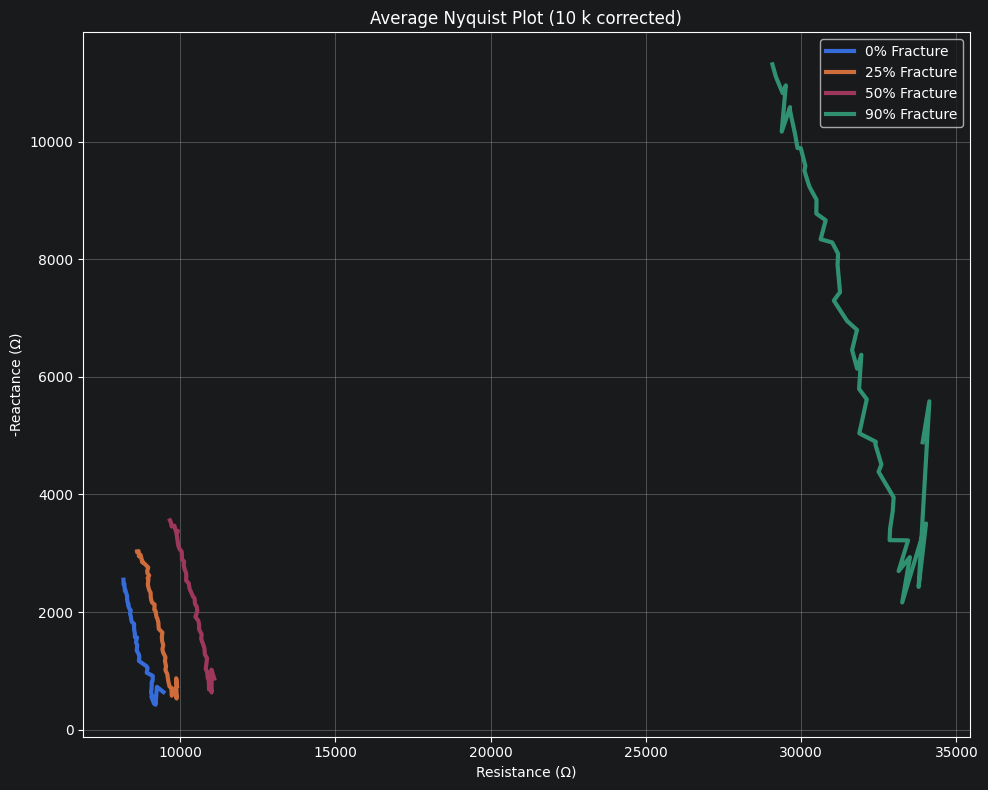

In [97]:
plt.figure(figsize=(10,8))

for condition, data in mean_curves.items():

    plt.plot(
        data["Resistance"],
        -data["Reactance"],
        linewidth=3,
        label=condition
    )

plt.xlabel("Resistance (Ω)")
plt.ylabel("-Reactance (Ω)")
plt.title("Average Nyquist Plot (10 k corrected)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Plot Phase Angle vs Frequency

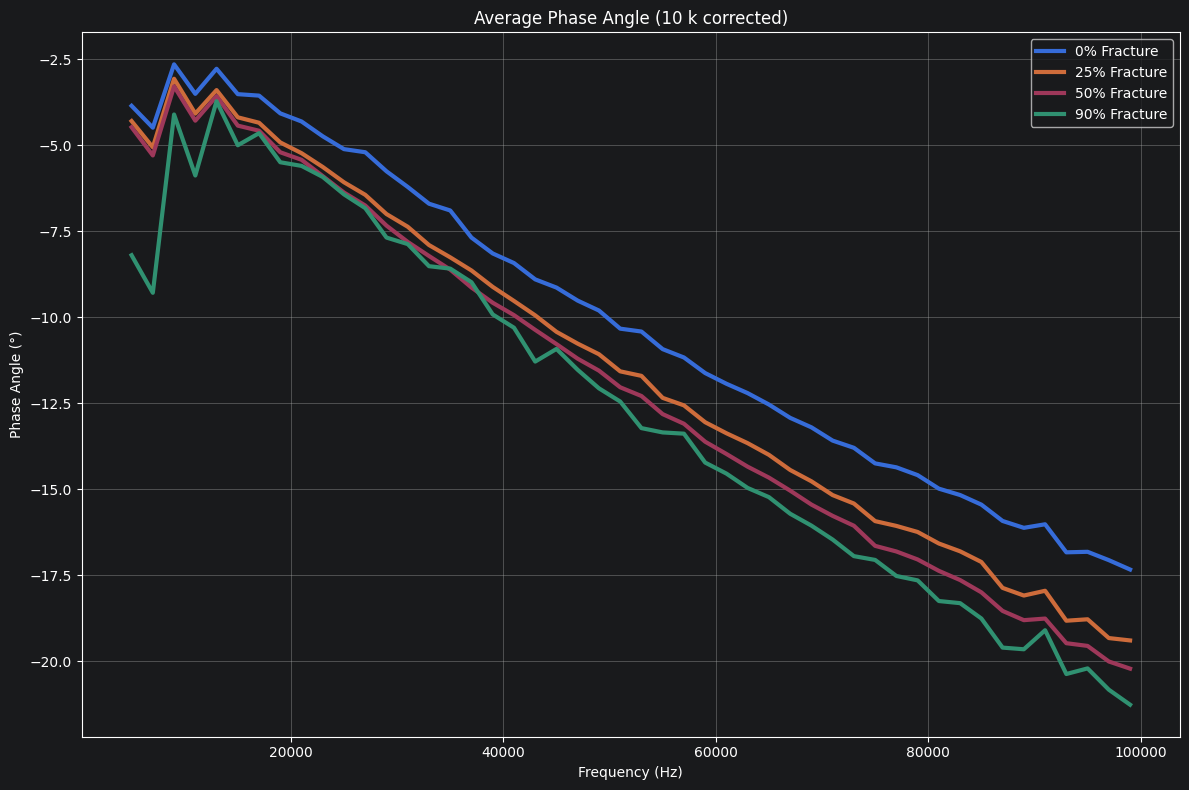

In [98]:
plt.figure(figsize=(12,8))

for condition, datasets in all_data.items():

    phase_matrix = np.column_stack([
        d["data"]["Phase"]
        for d in datasets
    ])

    mean_phase = np.mean(
        phase_matrix,
        axis=1
    )

    freq = datasets[0]["data"]["Frequency"]

    plt.plot(
        freq,
        mean_phase,
        linewidth=3,
        label=condition
    )

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase Angle (°)")
plt.title("Average Phase Angle (10 k corrected)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Quantify Separation

In [99]:
summary = []

for condition, datasets in all_data.items():

    resistance_values = []
    reactance_values = []

    for dataset in datasets:

        resistance_values.extend(
            dataset["data"]["Resistance"]
        )

        reactance_values.extend(
            dataset["data"]["Reactance"]
        )

    summary.append({

        "Condition": condition,

        "Mean Resistance":
            np.mean(resistance_values),

        "Std Resistance":
            np.std(resistance_values),

        "Mean Reactance":
            np.mean(reactance_values),

        "Std Reactance":
            np.std(reactance_values)
    })

summary_df = pd.DataFrame(summary)

summary_df

,Condition,Mean Resistance,Std Resistance,Mean Reactance,Std Reactance
0,0% Fracture,8645.929488,443.495693,-1520.098625,662.996758
1,25% Fracture,9249.774241,367.488790,-1850.534205,779.642988
2,50% Fracture,10394.431823,443.177279,-2174.785054,910.503439
3,90% Fracture,31471.325726,1456.050004,-6952.136318,2731.167847


In [100]:
print(mean_curves["0% Fracture"].keys())

dict_keys(['Resistance', 'Reactance', 'Phase', 'Resistance STD', 'Reactance STD', 'Phase STD'])


Phase Separation Analysis

In [101]:
# Reference (intact bone)
reference_phase = mean_curves["0% Fracture"]["Phase"]

freq = all_data["0% Fracture"][0]["data"]["Frequency"]

print("\n========== PHASE SEPARATION ==========\n")

for condition in [
    "25% Fracture",
    "50% Fracture",
    "90% Fracture"
]:

    phase = mean_curves[condition]["Phase"]

    separation = phase - reference_phase

    max_idx = np.argmax(np.abs(separation))

    print(f"\n{condition}")
    print(
        f"Maximum separation: "
        f"{abs(separation[max_idx]):.2f}°"
    )

    print(
        f"Frequency: "
        f"{freq.iloc[max_idx]:.0f} Hz"
    )

    print(
        f"Average separation: "
        f"{np.mean(np.abs(separation)):.2f}°"
    )


========== PHASE SEPARATION ==========


25% Fracture
Maximum separation: 2.26°
Frequency: 97000 Hz
Average separation: 1.32°

50% Fracture
Maximum separation: 2.94°
Frequency: 97000 Hz
Average separation: 1.82°

90% Fracture
Maximum separation: 4.80°
Frequency: 7000 Hz
Average separation: 2.49°


Separation vs Frequency

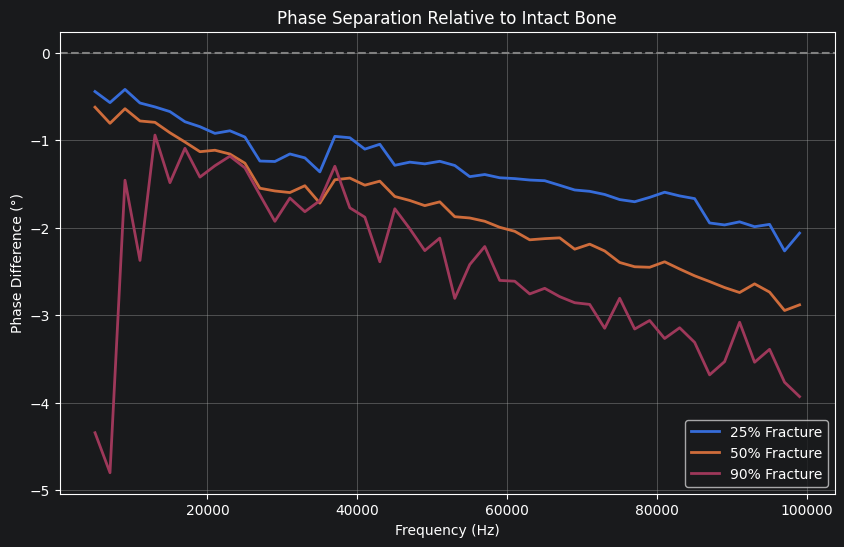

In [102]:
plt.figure(figsize=(10,6))

reference_phase = mean_curves["0% Fracture"]["Phase"]

freq = all_data["0% Fracture"][0]["data"]["Frequency"]

for condition in [
    "25% Fracture",
    "50% Fracture",
    "90% Fracture"
]:

    phase = mean_curves[condition]["Phase"]

    separation = phase - reference_phase

    plt.plot(
        freq,
        separation,
        linewidth=2,
        label=condition
    )

plt.axhline(
    0,
    color="gray",
    linestyle="--"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase Difference (°)")
plt.title("Phase Separation Relative to Intact Bone")
plt.legend()
plt.grid(True)

plt.show()

Normalize to percentage

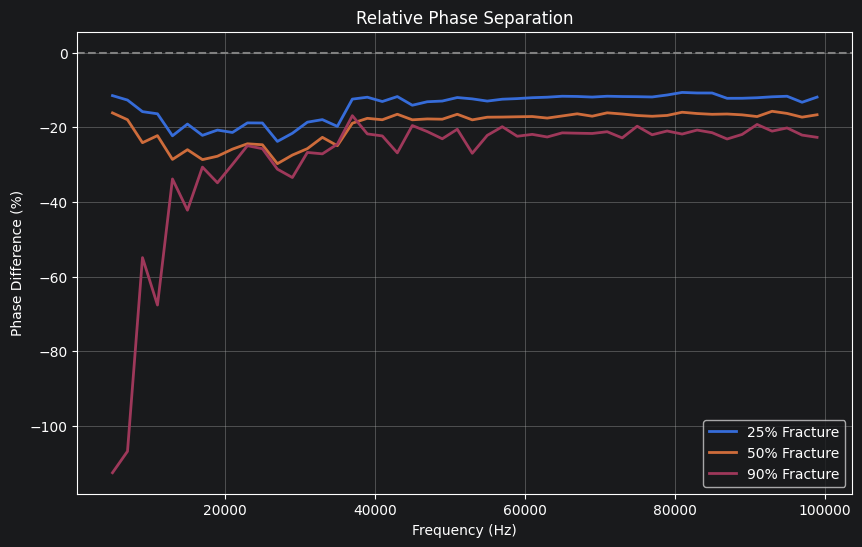

In [103]:
plt.figure(figsize=(10,6))

reference_phase = mean_curves["0% Fracture"]["Phase"]

freq = all_data["0% Fracture"][0]["data"]["Frequency"]

for condition in [
    "25% Fracture",
    "50% Fracture",
    "90% Fracture"
]:

    phase = mean_curves[condition]["Phase"]

    separation_percent = (
        (phase - reference_phase)
        / np.abs(reference_phase)
        * 100
    )

    plt.plot(
        freq,
        separation_percent,
        linewidth=2,
        label=condition
    )

plt.axhline(
    0,
    color="gray",
    linestyle="--"
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase Difference (%)")
plt.title("Relative Phase Separation")
plt.legend()
plt.grid(True)

plt.show()

In [104]:
print("\nMaximum separation from intact bone\n")

reference_phase = np.mean(
    np.column_stack([
        d["data"]["Phase"]
        for d in all_data["0% Fracture"]
    ]),
    axis=1
)

freq = all_data["0% Fracture"][0]["data"]["Frequency"]

for condition in [
    "25% Fracture",
    "50% Fracture",
    "90% Fracture"
]:

    phase = np.mean(
        np.column_stack([
            d["data"]["Phase"]
            for d in all_data[condition]
        ]),
        axis=1
    )

    separation = np.abs(
        phase - reference_phase
    )

    idx = np.argmax(separation)

    print(
        f"{condition}: "
        f"{separation[idx]:.2f}° "
        f"at {freq.iloc[idx]:.0f} Hz"
    )


Maximum separation from intact bone

25% Fracture: 2.26° at 97000 Hz
50% Fracture: 2.94° at 97000 Hz
90% Fracture: 4.80° at 7000 Hz


In [105]:
df

,Frequency,Resistance,Reactance,Phase,Impedance
0,5000.0,33882.656855,-5010.946104,-8.412561,34251.19
1,7000.0,34255.093159,-5523.644678,-9.160113,34697.58
2,9000.0,33986.587158,-2578.369919,-4.338396,34084.25
3,11000.0,34084.565724,-3488.187625,-5.843262,34262.59
4,13000.0,33350.197499,-2139.434123,-3.670527,33418.75
5,15000.0,33625.209285,-2991.975180,-5.084794,33758.06
6,17000.0,33083.417834,-2780.070582,-4.803402,33200.02
7,19000.0,33322.839402,-3267.449347,-5.600198,33482.65
8,21000.0,32867.374404,-3241.073506,-5.631767,33026.79
9,23000.0,33026.013014,-3472.517463,-6.002306,33208.07
